<div align="center">

# Caso de negocio RutaExpress

## Analisis descriptivo de una operacion de ultima milla

</div>

---

---

## 1. Contexto

RutaExpress es una startup de entregas de ultima milla que acaba de recibir una inversion fuerte para crecer. Trabaja con bicicletas, motos, carros y, como prueba piloto, drones de reparto en algunas zonas. El area de Operaciones necesita responder con datos, no solo con corazonadas, tres preguntas clave: si vale la pena meterle mas a los drones, que zona necesita atencion primero, y que tiempo de entrega es razonable prometerle a los clientes.

Para esto, revisamos una muestra de 1,500 entregas recientes con datos de zona, vehiculo, servicio, distancia, peso, tiempo de entrega, incidencias, calificacion del cliente y costo, buscando darle al comite directivo algo claro para decidir.

In [1]:
# Fast import definitions :3

# Analisis
import numpy as np
import pandas as pd

# Representation
from IPython.display import display
import matplotlib.pyplot as plt

In [2]:
np.random.seed(2026)
n_envios = 1500
zona_entrega = np.random.choice(
    ["Centro", "Norte", "Sur", "Poniente", "Oriente"],
    size=n_envios,
    p=[0.30, 0.20, 0.20, 0.15, 0.15],
)
tipo_vehiculo = np.random.choice(
    ["Bicicleta", "Motocicleta", "Automóvil", "Dron"],
    size=n_envios,
    p=[0.30, 0.40, 0.25, 0.05],
)
nivel_servicio = np.random.choice(
    ["Estándar", "Prioritario", "Express"], size=n_envios, p=[0.55, 0.30, 0.15]
)
distancia_km = np.random.gamma(shape=3.0, scale=1.8, size=n_envios).round(2)
peso_paquete_kg = np.random.gamma(shape=2.0, scale=1.1, size=n_envios).round(2)
paquetes_repartidor_dia = np.random.poisson(lam=14, size=n_envios)
incidencias_reportadas = np.random.poisson(lam=0.4, size=n_envios)
calificacion_cliente = np.random.choice(
    [1, 2, 3, 4, 5], size=n_envios, p=[0.03, 0.07, 0.15, 0.35, 0.40]
)
factor_vehiculo = (
    pd.Series(tipo_vehiculo)
    .map({"Bicicleta": 6.5, "Motocicleta": 3.8, "Automóvil": 4.5, "Dron": 2.0})
    .values
)
tiempo_base = distancia_km * factor_vehiculo + np.random.normal(5, 3, n_envios)
factor_zona = (
    pd.Series(zona_entrega)
    .map({"Centro": 1.0, "Norte": 1.05, "Sur": 1.35, "Poniente": 1.1, "Oriente": 1.15})
    .values
)
tiempo_entrega_min = tiempo_base * factor_zona
tiempo_entrega_min += incidencias_reportadas * np.random.uniform(15, 45, n_envios)
tiempo_entrega_min += incidencias_reportadas * np.random.uniform(15, 45, n_envios)
tiempo_entrega_min = np.clip(tiempo_entrega_min, 4, None).round(1)
costo_envio_mxn = (
    25
    + distancia_km * 4.2
    + peso_paquete_kg * 3.0
    + (nivel_servicio == "Express") * 35
    + (nivel_servicio == "Prioritario") * 15
    + np.random.normal(0, 5, n_envios)
).round(2)
costo_envio_mxn = np.clip(costo_envio_mxn, 20, None)

df = pd.DataFrame(
    {
        "envio_id": range(1, n_envios + 1),
        "zona_entrega": zona_entrega,
        "tipo_vehiculo": tipo_vehiculo,
        "nivel_servicio": nivel_servicio,
        "distancia_km": distancia_km,
        "peso_paquete_kg": peso_paquete_kg,
        "tiempo_entrega_min": tiempo_entrega_min,
        "paquetes_repartidor_dia": paquetes_repartidor_dia,
        "incidencias_reportadas": incidencias_reportadas,
        "calificacion_cliente": calificacion_cliente,
        "costo_envio_mxn": costo_envio_mxn,
    }
)

df.head()

,envio_id,zona_entrega,tipo_vehiculo,nivel_servicio,distancia_km,peso_paquete_kg,tiempo_entrega_min,paquetes_repartidor_dia,incidencias_reportadas,calificacion_cliente,costo_envio_mxn
0,1,Centro,Motocicleta,Prioritario,0.83,2.33,76.4,16,1,5,55.06
1,2,Norte,Motocicleta,Estándar,10.26,2.87,119.3,14,1,4,76.57
2,3,Oriente,Automóvil,Estándar,2.08,3.54,15.6,11,0,5,43.89
3,4,Centro,Bicicleta,Prioritario,3.54,2.28,28.8,12,0,2,54.41
4,5,Norte,Automóvil,Estándar,5.54,1.74,32.2,13,0,5,56.08


##

---
---

## 2. Clasificacion de datos

Para arrancar, vamos a clasificar los datos y ver que tipo de variables tenemos en la tabla. Primero necesitamos saber con que tipos de datos vamos a trabajar.

Con ese analisis inicial, sacamos el tipo y el subtipo de cada variable:

In [3]:
print("\n-------------------------------------------------------------------\n")
print("1. Identificacion de los tipos de datos obtenidos:\n")

display(pd.DataFrame(df.dtypes, columns=['Tipo de dato']))

print("\n-------------------------------------------------------------------\n")
print("2. Diferenciacion de cualitativas y cuantitativas, junto a sus subtipos:\n")

# quantitatives
quantitative_continuous = df.select_dtypes(include=['float']).columns.tolist()
quantitative_discrete = df.select_dtypes(include=['int']).columns.tolist()

# qualitatives
qualitatives = df.select_dtypes(exclude=['int', 'float']).columns.tolist()
qualitative_ordinal = ['nivel_servicio', 'calificacion_cliente']  #manual ;c
qualitative_nominal = [col for col in qualitatives if col not in qualitative_ordinal]

# table summary that indicates all types & subtypes
summary_types = []

for col in quantitative_continuous:
    summary_types.append({'Columna': col, 'Tipo': 'Cuantitativa', 'Subtipo': 'Continua'})

for col in quantitative_discrete:
    summary_types.append({'Columna': col, 'Tipo': 'Cuantitativa', 'Subtipo': 'Discreta'})

for col in qualitative_nominal:
    summary_types.append({'Columna': col, 'Tipo': 'Cualitativa', 'Subtipo': 'Nominal'})

for col in qualitative_ordinal:
    summary_types.append({'Columna': col, 'Tipo': 'Cualitativa', 'Subtipo': 'Ordinal'})

table_summary_types = pd.DataFrame(summary_types)

display(table_summary_types)

print("\n-------------------------------------------------------------------\n")


-------------------------------------------------------------------

1. Identificacion de los tipos de datos obtenidos:



,Tipo de dato
envio_id,int64
zona_entrega,str
tipo_vehiculo,str
nivel_servicio,str
distancia_km,float64
peso_paquete_kg,float64
tiempo_entrega_min,float64
paquetes_repartidor_dia,int64
incidencias_reportadas,int64
calificacion_cliente,int64



-------------------------------------------------------------------

2. Diferenciacion de cualitativas y cuantitativas, junto a sus subtipos:



,Columna,Tipo,Subtipo
0,distancia_km,Cuantitativa,Continua
1,peso_paquete_kg,Cuantitativa,Continua
2,tiempo_entrega_min,Cuantitativa,Continua
3,costo_envio_mxn,Cuantitativa,Continua
4,envio_id,Cuantitativa,Discreta
5,paquetes_repartidor_dia,Cuantitativa,Discreta
6,incidencias_reportadas,Cuantitativa,Discreta
7,calificacion_cliente,Cuantitativa,Discreta
8,zona_entrega,Cualitativa,Nominal
9,tipo_vehiculo,Cualitativa,Nominal



-------------------------------------------------------------------



Con las variables ya identificadas, podemos entender mejor que se puede hacer con este dataset y que no. Por ejemplo, veamos un caso hipotetico: alguien quiere convertir la variable `nivel_servicio` en numeros enteros (con la excusa de "ahorrar espacio" en la base de datos), y vamos a explicar por que eso seria un error que no suma nada.

#### 2.1 El error de interpretacion

Si codificamos `nivel_servicio` como `1 = Estandar`, `2 = Prioritario`, `3 = Express`, y sacamos el promedio de esa columna diciendo *"el promedio es 1.6"*, estamos cometiendo un error: tratamos una variable ordinal como si fuera de intervalos exactos, y eso no tiene mucho sentido.

Eso implica suponer que la distancia entre `Estandar` -> `Prioritario` es igual a la distancia entre `Prioritario` -> `Express`, pero en realidad esos numeros son arbitrarios y no representan una magnitud fija. Un 1.6 no corresponde a ningun nivel real del proceso.

#### 2.2 Que si funcionaria con esa codificacion numerica

- **Moda**: el nivel de servicio mas frecuente.
- **Mediana**: el valor de en medio al ordenar los datos.
- **Tablas de frecuencia**: que porcentaje de envios cae en cada nivel.
- **Comparaciones de orden**: sirve para saber cual va antes o despues.

#### 2.3 Que NO funcionaria

- **Media aritmetica**: es el error que mencionamos arriba.
- **Desviacion estandar o varianza**: tienen el mismo problema de asumir distancias iguales.

##

---
---

## 3. Medidas de tendencia central

Ahora que ya tenemos las variables claras y ordenadas, podemos empezar con los analisis basicos para encontrar los valores clave de los datos. Asi el personal puede usar estos resultados en casos concretos para tomar decisiones.

### 3.1 Medidas basicas en tiempos de entrega

Vamos a hacer este analisis con la columna `tiempo_entrega_min`, porque es la que nos da resultados mas utiles y representativos para la empresa en comparacion con otras opciones.


-------------------------------------------------------------------

1. Identificacion de las medidas centrales



,Medida,Valor (min)
0,Media,58.540933
1,Mediana,45.050000
2,Moda,21.700000



-------------------------------------------------------------------

2. Histograma representativo 



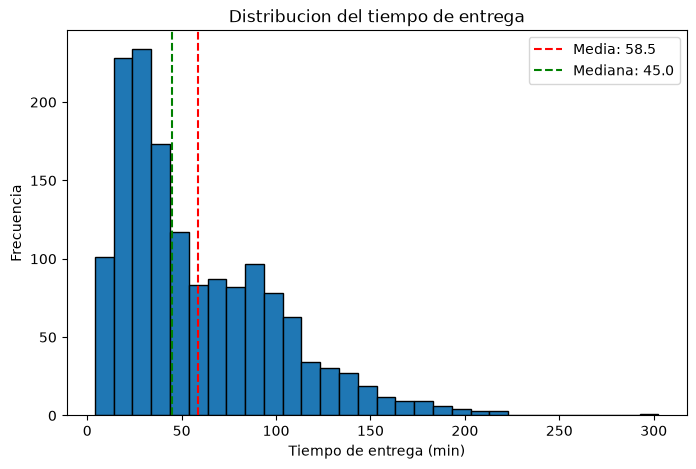


-------------------------------------------------------------------



In [4]:
tiempo_entrega_min_mean = df['tiempo_entrega_min'].mean()
tiempo_entrega_min_median = df['tiempo_entrega_min'].median()
tiempo_entrega_min_mode = df['tiempo_entrega_min'].mode()[0]

table_tiempo_entrega_min_central = pd.DataFrame({
    'Medida': ['Media', 'Mediana', 'Moda'],
    'Valor (min)': [tiempo_entrega_min_mean, tiempo_entrega_min_median, tiempo_entrega_min_mode]
})

print("\n-------------------------------------------------------------------\n")
print("1. Identificacion de las medidas centrales\n")

display(table_tiempo_entrega_min_central)

print("\n-------------------------------------------------------------------\n")
print("2. Histograma representativo \n")

plt.figure(figsize=(8, 5))
plt.hist(df['tiempo_entrega_min'], bins=30, edgecolor='black')
plt.axvline(tiempo_entrega_min_mean, color='red', linestyle='--', label=f'Media: {tiempo_entrega_min_mean:.1f}')
plt.axvline(tiempo_entrega_min_median, color='green', linestyle='--', label=f'Mediana: {tiempo_entrega_min_median:.1f}')
plt.xlabel('Tiempo de entrega (min)')
plt.ylabel('Frecuencia')
plt.title('Distribucion del tiempo de entrega')
plt.legend()
plt.show()

print("\n-------------------------------------------------------------------\n")


Con solo mirar la muestra no se nota muy claro como se comportan las entregas, pero con un histograma ya podemos verlo mejor de forma visual. Y ahi se nota que la **mediana** es la que mejor representa lo que pasa.

El motivo es simple: la mediana no se ve afectada por casos raros que desajustan el promedio. Por ejemplo, si una entrega se demoro 8 horas por algo extraordinario, el promedio se dispara y ya no representa bien la realidad. En cambio, la mediana solo necesita que los datos esten ordenados de menor a mayor y toma el valor de en medio, sin importar que tan extremos sean los otros valores.

La moda la dejamos de lado en este caso porque no nos sirve para entender el comportamiento general de los datos, solo nos dice cual es el valor que mas se repite.

Con esto claro, si queremos fijar un tiempo de entrega, la mediana es la metrica mas confiable y realista para el negocio. Asi evitamos prometer algo que se ve afectado por casos raros.

### 3.2 Aplicacion en campaña de marketing

Con base en lo que vimos en la seccion 3.1, la respuesta esta clara: seguimos usando la mediana como la opcion mas realista para definir el valor de `X`.

La moda llama la atencion al principio porque suena como algo que le podriamos garantizar al cliente, casi como un slogan. Pero como esta variable es continua y tiene decimales, es dificil tener una moda que realmente represente donde se concentran mas los datos. De hecho, en el histograma la moda no cae justo donde hay mas valores juntos.

Por otro lado, la media tiene el mismo problema de siempre: si hay fallas logisticas, de entrega o tecnicas, la media se dispara y podriamos terminar prometiendo tiempos que no se cumplen en la realidad.

Al final, la mediana es la que mejor muestra cuanto tardan realmente los envios (como vimos en la seccion 3.1). Aun asi, no es un numero perfecto para marketing porque siempre hay casos que tardan bastante mas que la mediana. Por eso el valor de `X` deberia ser un poco mas alto que la mediana, para tener un margen de seguridad. Por ejemplo, si la mediana es `58.5`, podriamos poner ese X en `70` para ir mas seguros.

### 3.3 Mejor vehiculo de entregas

Ya vimos que la mediana es el numero mas confiable para representar el tiempo de envio, pero todavia no sabemos que vehiculos cumplen mejor con las entregas. Por eso vamos a calcular la mediana por cada tipo de vehiculo de la empresa, para sacar conclusiones sobre la flota actual y poder tomar decisiones con base en los datos.


-------------------------------------------------------------------

1. Mediana por vehiculo 



,Tipo de vehiculo,Mediana tiempo entrega (min)
0,Automóvil,40.30
1,Bicicleta,59.65
2,Dron,19.75
3,Motocicleta,39.50



-------------------------------------------------------------------

2. Informacion de los vehiculos complementaria 



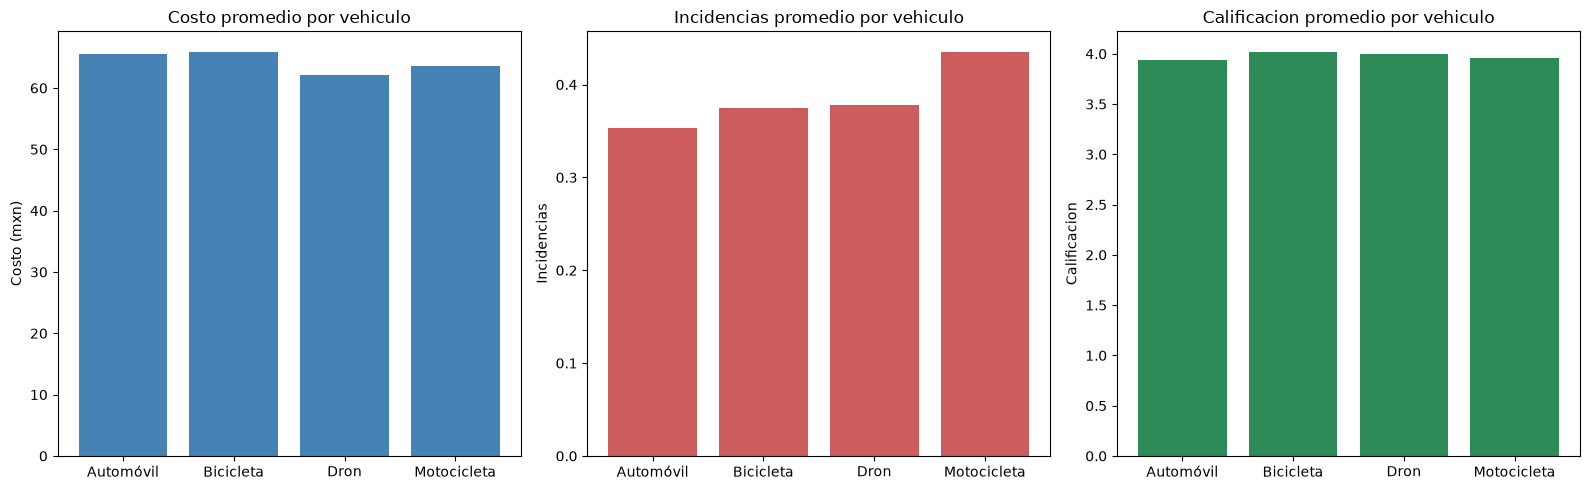


-------------------------------------------------------------------



In [5]:
print("\n-------------------------------------------------------------------\n")

print("1. Mediana por vehiculo \n")

vehicle_median_delivery_time = df.groupby('tipo_vehiculo')['tiempo_entrega_min'].median().reset_index()
vehicle_median_delivery_time.columns = ['Tipo de vehiculo', 'Mediana tiempo entrega (min)']
display(vehicle_median_delivery_time)

print("\n-------------------------------------------------------------------\n")

print("2. Informacion de los vehiculos complementaria \n")


vehicle_summary = df.groupby('tipo_vehiculo').agg(
    delivery_count=('tiempo_entrega_min', 'count'),
    avg_cost=('costo_envio_mxn', 'mean'),
    avg_incidents=('incidencias_reportadas', 'mean'),
    avg_rating=('calificacion_cliente', 'mean')
).reset_index()

vehicle_summary.columns = ['Tipo de vehiculo', 'Cantidad de envios', 'Costo promedio (mxn)', 'Incidencias promedio', 'Calificacion promedio']


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(vehicle_summary['Tipo de vehiculo'], vehicle_summary['Costo promedio (mxn)'], color='steelblue')
axes[0].set_title('Costo promedio por vehiculo')
axes[0].set_ylabel('Costo (mxn)')

axes[1].bar(vehicle_summary['Tipo de vehiculo'], vehicle_summary['Incidencias promedio'], color='indianred')
axes[1].set_title('Incidencias promedio por vehiculo')
axes[1].set_ylabel('Incidencias')

axes[2].bar(vehicle_summary['Tipo de vehiculo'], vehicle_summary['Calificacion promedio'], color='seagreen')
axes[2].set_title('Calificacion promedio por vehiculo')
axes[2].set_ylabel('Calificacion')

plt.tight_layout()
plt.show()

print("\n-------------------------------------------------------------------\n")

Con este analisis encontramos varios datos interesantes. El mas importante es que los drones tienen tiempos de entrega mucho mas rapidos que cualquier otro medio de transporte que usa la empresa.

Ademas sacamos otros datos que sirven para tomar decisiones sobre la flota de vehiculos. Los drones no solo son los mas rapidos, tambien tienen las mejores calificaciones y la tasa mas baja de incidentes. Los demas vehiculos, en cambio, tienen cifras bastante parecidas entre si, lo que nos dice que su eficiencia operativa es similar entre ellos.

Aun asi, la flota de drones es la mejor opcion, porque en el tiempo que un vehiculo tradicional hace una entrega, un dron puede hacer dos o tres. La unica duda que queda es en cuanto tiempo el dron recupera su inversion y empieza a dar ganancias.

##

---
---

## 4. Medidas de dispersion

Ahora vamos a ver que tan dispersos estan los datos, es decir, que tan comunes son los casos raros y que tanto le pegan a la empresa cuando pasan. Con esto podemos comparar la informacion que tenemos y facilitar la toma de decisiones.

### 4.1 Consistencia de entrega

Primero vamos a ver que tan parejo o irregular es el servicio de entrega, porque un mismo promedio puede esconder entregas muy rapidas mezcladas con otras muy lentas. Para eso calculamos la desviacion estandar y el coeficiente de variacion de `tiempo_entrega_min`.

In [6]:
print("\n-------------------------------------------------------------------\n")

std_delivery_time = df['tiempo_entrega_min'].std()
mean_delivery_time = df['tiempo_entrega_min'].mean()

cv_delivery_time = (std_delivery_time / mean_delivery_time) * 100

print(f"Desviacion estandar: {std_delivery_time:.2f} min")
print(f"Coeficiente de variacion: {cv_delivery_time:.2f}%")

print("\n-------------------------------------------------------------------\n")


-------------------------------------------------------------------

Desviacion estandar: 41.72 min
Coeficiente de variacion: 71.27%

-------------------------------------------------------------------



El servicio de entregas no es consistente. El coeficiente de variacion de `71.27%` muestra una dispersion muy alta en los tiempos de entrega, bien por encima del 30% que se considera "alta variabilidad". Esto se confirma con la diferencia entre la media (58.54 min), la mediana (45.05 min) y la moda (21.70) que ya vimos antes. En otras palabras, la mayoria de las entregas son bastante mas rapidas que el promedio, pero un grupo de entregas con demoras grandes esta inflando la media, lo que genera una distribucion sesgada hacia la derecha.

### 4.2 Comparativa del tiempo de entrega por zona

Ya vimos que tan dispersos son los tiempos de entrega en general, pero esa dispersion puede no ser igual en todas las zonas. Puede haber zonas donde el servicio es mas predecible, y otras donde es mas inestable, aunque tengan tiempos promedio parecidos.

In [7]:
print("\n-------------------------------------------------------------------\n")

zone_stats = df.groupby('zona_entrega')['tiempo_entrega_min'].agg(
    mean='mean',
    std='std'
).reset_index()

zone_stats['cv'] = (zone_stats['std'] / zone_stats['mean']) * 100

zone_stats.columns = ['Zona de entrega', 'Media (min)', 'Desviacion estandar (min)', 'Coeficiente de variacion (%)']

display(zone_stats)

print("\n-------------------------------------------------------------------\n")


-------------------------------------------------------------------



,Zona de entrega,Media (min),Desviacion estandar (min),Coeficiente de variacion (%)
0,Centro,54.976611,39.382973,71.635869
1,Norte,57.167974,43.354438,75.836933
2,Oriente,59.619665,42.408485,71.131705
3,Poniente,57.910599,40.149170,69.329571
4,Sur,64.160188,43.256169,67.419019



-------------------------------------------------------------------



Aqui notamos que la zona mas llamativa es la Norte. Su tiempo promedio (57.17 min) es parecido al de otras zonas como Poniente o Centro, pero tiene el coeficiente de variacion mas alto de todas (75.84%). De hecho, es mas alto que el de Sur, que tiene el promedio mas alto pero el CV mas bajo (67.42%).

Esto significa que un promedio parecido no garantiza una experiencia parecida. En Norte hay una mezcla de entregas muy rapidas y muy lentas, asi que dos clientes de esa zona pueden vivir experiencias muy distintas aunque el promedio se vea normal.

Para el cliente esto se siente como incertidumbre, porque no sabe si su entrega va a llegar rapido o tarde. Por eso, mas que bajar el promedio de la zona Norte, lo importante seria investigar por que hay tanta variabilidad ahi. Por ejemplo, si hay subzonas muy distintas, si hay inconsistencia en el vehiculo o la carga de paquetes asignada, o si hay horas del dia donde se generan retrasos puntuales. La meta no es solo entregar rapido en promedio, sino entregar de forma consistente.

### 4.3 Evaluacion de costos de envio

Asi como comparamos la consistencia del tiempo de entrega por zona, tambien es util ver que tan predecible es el costo del envio en cada nivel de servicio. Esto importa si se quiere ofrecer un precio fijo por nivel, porque un promedio parecido no garantiza que el costo real sea igual de estable.

In [8]:
print("\n-------------------------------------------------------------------\n")

service_level_stats = df.groupby('nivel_servicio')['costo_envio_mxn'].agg(
    mean='mean',
    std='std'
).reset_index()

service_level_stats['cv'] = (service_level_stats['std'] / service_level_stats['mean']) * 100

service_level_stats.columns = ['Nivel de servicio', 'Media (mxn)', 'Desviacion estandar (mxn)', 'Coeficiente de variacion (%)']

display(service_level_stats)

print("\n-------------------------------------------------------------------\n")


-------------------------------------------------------------------



,Nivel de servicio,Media (mxn),Desviacion estandar (mxn),Coeficiente de variacion (%)
0,Estándar,54.572204,15.001060,27.488464
1,Express,89.783020,15.853684,17.657776
2,Prioritario,70.120548,15.823910,22.566723



-------------------------------------------------------------------



El servicio Express es el mas predecible, porque tiene el coeficiente de variacion mas bajo de los tres (17.66%). Estandar tiene el mas alto (27.49%), y Prioritario queda en un punto intermedio (22.57%).

Los tres niveles se ven parecidos a simple vista, sin una diferencia grande en su variacion. Pero como Express tiene un costo promedio mucho mas alto (89.78 mxn) que Estandar (54.57 mxn), esa misma variacion en pesos pesa mucho menos sobre su costo total. Por eso el CV muestra la diferencia real de consistencia, no la desviacion estandar sola.

Si se quiere ofrecer un precio fijo garantizado, Express es el nivel mas seguro para hacerlo, porque su costo real se mantiene cerca de su promedio. En cambio, Estandar es el mas riesgoso: al tener mas variabilidad, hay mas envios cuyo costo real se aleja bastante del promedio, y eso podria generar perdidas.

##

---
---

## 5. Medidas de sesgo y curtosis

Hasta ahora vimos que tan dispersos estan los datos, pero no que tan simetrica es esa dispersion ni si hay valores extremos que se repiten mas de lo normal. Por eso calculamos el sesgo y la curtosis, que nos ayudan a entender la forma real de la distribucion y a confirmar si medidas como la media estan siendo afectadas por datos atipicos.

### 5.1 Frecuencia de entregas problematicas

Empezamos calculando el sesgo y la curtosis, que nos dicen mas sobre la forma real de la distribucion de los tiempos de entrega.

In [9]:
skewness_delivery_time = df['tiempo_entrega_min'].skew()
kurtosis_delivery_time = df['tiempo_entrega_min'].kurt()

print(f"Sesgo: {skewness_delivery_time:.2f}")
print(f"Curtosis: {kurtosis_delivery_time:.2f}")

Sesgo: 1.15
Curtosis: 1.34


Primero, el sesgo fue positivo y bastante notorio (1.15). Al ser positivo, nos dice que la distribucion tiene una cola larga hacia la derecha, porque hay un grupo de entregas con tiempos mucho mas altos que jalan la distribucion hacia ese lado. Este valor se considera un sesgo fuerte, no uno leve, es decir, es evidencia clara de que la distribucion no es simetrica, no se parece a una campana.

Segundo, la curtosis fue positiva y leptocurtica (1.34). Esto quiere decir que la distribucion tiene colas mas pesadas que una distribucion normal, o sea, hay mas valores extremos de los que uno esperaria en los tiempos de entrega.

Si la distribucion fuera simetrica y con colas normales, esperariamos que los retrasos grandes fueran cosa rara. Pero aqui el sesgo positivo muestra que un grupo especifico de entregas lentas empuja los tiempos hacia arriba de forma constante, y la curtosis alta confirma que esos casos extremos aparecen mas seguido de lo esperado.

Esto refuerza lo que ya habiamos visto con el coeficiente de variacion (71.27%): el servicio no solo es muy variable, tambien tiene un problema recurrente de entregas atrasadas, no es solo variabilidad al azar. En la practica, esto sugiere buscar una causa comun detras de esos retrasos (zona, tipo de vehiculo, franja horaria) en lugar de tratarlos como casos sueltos.

### 5.2 Uso de tiempo_entrega_min en un futuro modelo predictivo

Si el sesgo de `tiempo_entrega_min` se mantiene alto (1.15, sesgo fuerte hacia la derecha), no seria buena idea usar esta variable tal cual en un futuro modelo predictivo sin antes hacerle algun tratamiento. Un sesgo tan marcado suele complicar a los modelos que asumen relaciones lineales o distribuciones normales, como la regresion lineal clasica, y eso genera predicciones poco confiables para los casos extremos.

Antes de usarla tal cual, le recomendariamos al equipo de datos:

- **Aplicar una transformacion** (por ejemplo logaritmica o Box-Cox) para bajarle a la asimetria y acercar la distribucion a algo mas simetrico, sobre todo si se va a usar un modelo sensible a la escala o a la normalidad de los datos.
- **Revisar los valores atipicos**, viendo si los tiempos muy altos son errores al capturar los datos, incidencias reales, o un patron operativo que vale la pena modelar aparte.
- **Considerar modelos mas resistentes a distribuciones sesgadas**, como arboles de decision o ensambles (random forest, gradient boosting), que no asumen normalidad y manejan mejor las colas largas sin tener que transformar la variable.

En resumen, usar la variable tal cual sin mirar su forma podria hacer que el modelo aprenda mal el comportamiento de las entregas mas lentas, que son justo las que mas le importan al negocio.

### 5.3 Riesgo operativo y politica de compensacion

Una curtosis alta (1.34, leptocurtica) quiere decir que la distribucion de tiempos de entrega tiene colas mas pesadas que una distribucion normal. En otras palabras, los retrasos extremos no son tan raros como uno pensaria si los tiempos se comportaran como una campana perfecta. En terminos de riesgo operativo, esto significa que, aunque las entregas muy tardias sigan siendo poco comunes, la probabilidad de que pasen es mayor de lo que uno esperaria en un negocio normal.

Esto deberia influir directamente en como se diseña una politica de compensacion o reembolso por entregas tardias. Si RutaExpress arma esa politica pensando que los retrasos extremos son casos aislados y raros, corre el riesgo de calcular mal cuantas veces va a tener que compensar a un cliente, y eso puede traer sorpresas en las finanzas. En cambio, si se reconoce que estos casos son mas probables de lo normal, tiene mas sentido:

- Definir una **politica de compensacion escalonada**, donde el reembolso o beneficio crezca segun que tan tarde llego la entrega, en vez de un esquema de todo o nada.
- Mantener un **colchon operativo** (por ejemplo, personal o vehiculos de respaldo) pensado justo para esos picos de retraso, en lugar de calcular la operacion solo para el caso promedio.
- Revisar estos casos extremos de forma seguida, ya que la curtosis alta sugiere que son parte normal del servicio y no simples excepciones.

##

---
---

## 6. Visualizacion de datos

Hasta ahora describimos los datos con numeros (medias, medianas, dispersion, sesgo y curtosis), pero una imagen ayuda a que estos hallazgos se entiendan y se confirmen mas facil. En esta seccion mostramos graficamente la forma de la distribucion del tiempo de entrega y comparamos que tan consistentes son la zona mas estable y la menos estable.

### 6.1 Distribucion del tiempo de entrega


-------------------------------------------------------------------

1. Histograma del tiempo de entrega con media y mediana



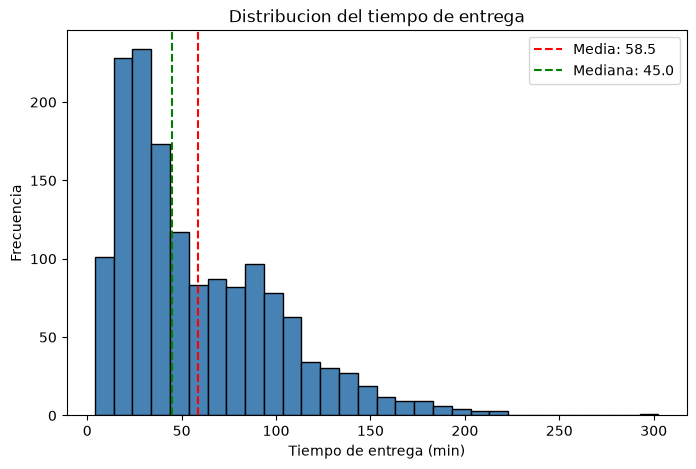


-------------------------------------------------------------------



In [10]:
print("\n-------------------------------------------------------------------\n")
print("1. Histograma del tiempo de entrega con media y mediana\n")

tiempo_entrega_min_mean = df['tiempo_entrega_min'].mean()
tiempo_entrega_min_median = df['tiempo_entrega_min'].median()

plt.figure(figsize=(8, 5))
plt.hist(df['tiempo_entrega_min'], bins=30, color='steelblue', edgecolor='black')
plt.axvline(tiempo_entrega_min_mean, color='red', linestyle='--', label=f'Media: {tiempo_entrega_min_mean:.1f}')
plt.axvline(tiempo_entrega_min_median, color='green', linestyle='--', label=f'Mediana: {tiempo_entrega_min_median:.1f}')
plt.xlabel('Tiempo de entrega (min)')
plt.ylabel('Frecuencia')
plt.title('Distribucion del tiempo de entrega')
plt.legend()
plt.show()

print("\n-------------------------------------------------------------------\n")

El histograma confirma visualmente lo que ya habiamos calculado con el sesgo en la Seccion 5: la distribucion no es simetrica, tiene una cola larga hacia la derecha. La mayoria de las entregas se concentran en tiempos bajos, cerca de la mediana (45.05 min), pero hay un grupo de entregas con tiempos mucho mas altos que estira la distribucion hacia la derecha y separa la media (58.54 min) de la mediana.

Esta forma es justo la que corresponde a un sesgo positivo como el que calculamos (1.15): unas pocas entregas muy lentas bastan para mover el promedio, mientras que la mediana se queda mas cerca de lo que realmente vive la mayoria de los clientes.

### 6.2 Comparacion de consistencia entre zonas (Sur vs Norte)


-------------------------------------------------------------------

1. Densidad del tiempo de entrega: zona Sur vs zona Norte



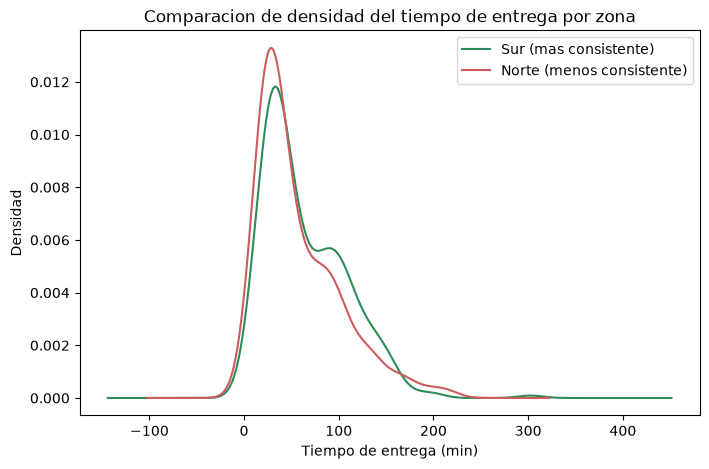


-------------------------------------------------------------------



In [11]:
print("\n-------------------------------------------------------------------\n")
print("1. Densidad del tiempo de entrega: zona Sur vs zona Norte\n")

plt.figure(figsize=(8, 5))
df[df['zona_entrega'] == 'Sur']['tiempo_entrega_min'].plot(kind='kde', color='seagreen', label='Sur (mas consistente)')
df[df['zona_entrega'] == 'Norte']['tiempo_entrega_min'].plot(kind='kde', color='indianred', label='Norte (menos consistente)')
plt.xlabel('Tiempo de entrega (min)')
plt.ylabel('Densidad')
plt.title('Comparacion de densidad del tiempo de entrega por zona')
plt.legend()
plt.show()

print("\n-------------------------------------------------------------------\n")

En la Seccion 4.2 vimos que la zona Sur tiene el coeficiente de variacion mas bajo (67.42%) y la zona Norte el mas alto (75.84%), aunque tienen tiempos promedio parecidos. La grafica de densidad muestra esa diferencia de forma visual: la curva de Norte es mas ancha y aplanada, lo que indica que sus tiempos de entrega estan mas dispersos y son menos predecibles. La curva de Sur, en cambio, esta un poco mas junta alrededor de su valor central.

Esto respalda la decision de intervenir primero la zona Norte antes que Sur. No porque Norte tenga el peor promedio, sino porque su servicio es el menos consistente, y eso genera experiencias de cliente muy distintas dentro de la misma zona.

##

---
---

## 7. Sintesis y decision gerencial

Despues de revisar la tendencia central, la dispersion y la forma de la distribucion del tiempo de entrega, cerramos el analisis con una recomendacion para el Director de Operaciones y con las limitaciones que debe tener en cuenta antes de decidir.

### 7.1 Memo ejecutivo para el Director de Operaciones

Para: Director de Operaciones de RutaExpress
De: Equipo de Analisis de Datos
Asunto: Recomendaciones del analisis descriptivo de 1,500 entregas

Sobre la expansion de drones: los datos apoyan hacerlo. Los drones tienen una mediana de tiempo de entrega de 19.75 min, muy por debajo de motos (39.50 min), automoviles (40.30 min) y bicicletas (59.65 min), y ademas tienen las mejores calificaciones y menos incidencias. Recomendamos ampliar la flota de drones poco a poco, empezando por las zonas donde su uso sea viable.

Sobre la zona prioritaria: recomendamos intervenir primero la zona Norte. No tiene el peor promedio (57.17 min), pero si tiene el coeficiente de variacion mas alto (75.84%), lo que significa que su servicio es el menos predecible y genera experiencias muy distintas entre clientes de la misma zona.

Sobre el tiempo de entrega a prometer: sugerimos comunicar un SLA cercano a 70 minutos. La mediana actual es de 45.05 min, pero el sesgo positivo (1.15) y la curtosis alta (1.34) muestran que los retrasos extremos pasan mas seguido de lo normal, asi que prometer la mediana exacta seria arriesgado.

Quedamos atentos a sus comentarios.

### 7.2 Limitaciones del analisis

Antes de decidir con base en estas recomendaciones, hay que tener en cuenta que este es un analisis descriptivo, no inferencial ni causal. Las diferencias que vimos entre vehiculos, zonas y niveles de servicio muestran que hay una relacion en los datos, pero no prueban que, por ejemplo, cambiar el tipo de vehiculo vaya a reducir directamente el tiempo de entrega. Podria haber otros factores de fondo (como el tipo de zona donde mas se usan los drones) explicando parte de esa diferencia.

Ademas, el dataset no incluye variables que en la practica afectan mucho el tiempo de entrega, como el clima, la hora del dia, el trafico real o la carga de trabajo del repartidor en ese momento. Agregar esas variables en un analisis futuro ayudaria a confirmar si las recomendaciones de este memo se sostienen en distintas condiciones operativas.